## Executive Summary

This analysis explores how trader performance and behavior change under different market sentiment conditions using the Fear & Greed Index and historical trading data.

Key findings include:

• Trading activity increases significantly during **Fear and Extreme Fear** market conditions, indicating heightened market participation during volatility.

• Trader profitability varies across sentiment regimes, with some sentiment environments producing higher average returns.

• Profit distribution is highly concentrated, with a small number of traders generating the majority of total profits.

These insights suggest that **market sentiment plays a significant role in shaping trader behavior and risk-taking patterns**, and sentiment indicators can provide valuable context when analyzing trading performance.

# Trader Behavior vs Market Sentiment Analysis
### Data Science Internship Project

This project analyzes the relationship between market sentiment
(Fear & Greed Index) and trader behavior using historical trading data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Objective

The goal of this project is to analyze how market sentiment affects
trader behavior and profitability.

Key questions explored:

- Do traders perform better during fear or greed markets?
- How does buy/sell behavior change with sentiment?
- Which traders generate the highest profits?
- How does trading volume vary across market conditions?

In [2]:
sentiment = pd.read_csv("data/fear_greed_index.csv")
trades = pd.read_csv("data/historical_data.csv")

sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [3]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## Dataset Description

Two datasets were used in this project.

### 1. Fear & Greed Index Dataset
This dataset provides daily market sentiment values.

Sentiment categories include:
- Extreme Fear
- Fear
- Neutral
- Greed
- Extreme Greed

### 2. Historical Trading Dataset
This dataset contains trader transaction records including:

- Trader account
- Execution price
- Position size
- Trade direction (Buy/Sell)
- Realized profit or loss (Closed PnL)

print("Sentiment dataset shape:", sentiment.shape)
print("Trader dataset shape:", trades.shape)

In [4]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [5]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [6]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [7]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [8]:
sentiment.duplicated().sum()

np.int64(0)

In [9]:
trades.duplicated().sum()

np.int64(0)

trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"], dayfirst=True)
trades["date"] = trades["Timestamp IST"].dt.date

In [10]:
sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

In [11]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [12]:
trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"], dayfirst=True)

In [13]:
trades["date"] = trades["Timestamp IST"].dt.date

## Dataset Merging

To analyze trader performance relative to market sentiment, the trading dataset is merged with the Fear & Greed sentiment dataset.

The merge is performed using the **date column**, which allows us to align each trade with the corresponding market sentiment on that day.

A **left join** is used so that all trading records are preserved while adding sentiment information where available.

In [14]:
merged = trades.merge(sentiment, on="date", how="left")

In [15]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [16]:
merged["classification"].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

## Profitability by Market Sentiment

In this section, we analyze how trader profitability varies across different market sentiment conditions such as:

- Extreme Fear
- Fear
- Neutral
- Greed
- Extreme Greed

The goal is to determine whether certain sentiment environments are more favorable for profitable trading.

In [17]:
sentiment_pnl = merged.groupby("classification")["Closed PnL"].mean().sort_values()

sentiment_pnl

classification
Neutral          34.307718
Extreme Fear     34.537862
Greed            42.743559
Fear             54.290400
Extreme Greed    67.892861
Name: Closed PnL, dtype: float64

## Exploratory Data Analysis

To understand trader behavior under different market sentiment conditions, we visualize key metrics such as profit distribution, trading volume, and trader performance across sentiment categories.

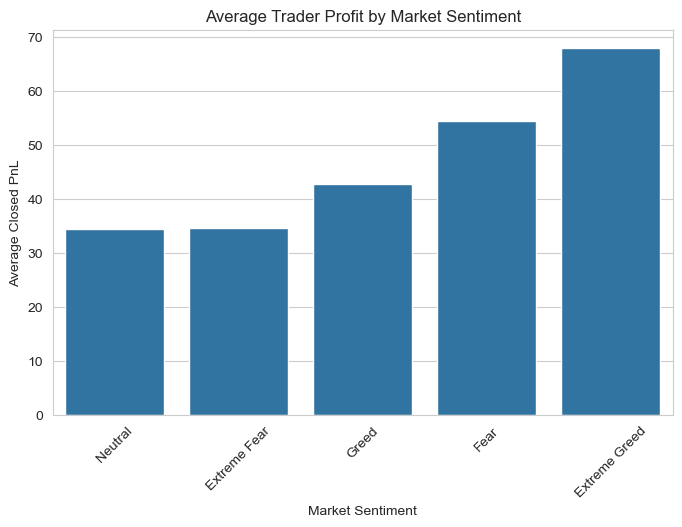

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=sentiment_pnl.index,
    y=sentiment_pnl.values
)

plt.title("Average Trader Profit by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)

plt.show()

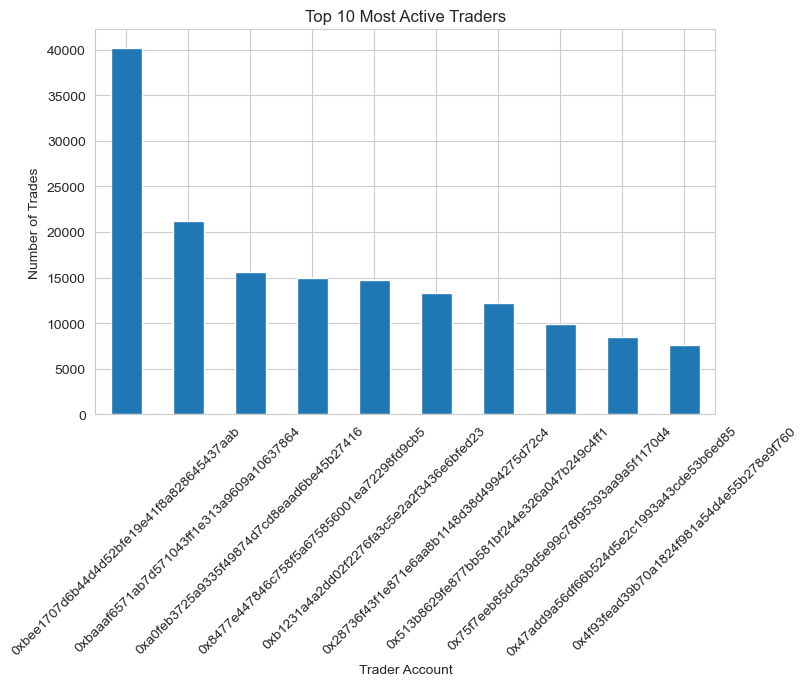

In [19]:
# Trader activity segmentation
trader_activity = merged.groupby("Account").size().sort_values(ascending=False)

plt.figure(figsize=(8,5))
trader_activity.head(10).plot(kind="bar")
plt.title("Top 10 Most Active Traders")
plt.xlabel("Trader Account")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.show()

## Trader Segmentation

To understand behavioral differences among traders, we analyze trading activity by account.

The chart above highlights the most active traders in the dataset.  
This helps identify trader segments such as:

• **High-frequency traders** who execute many trades  
• **Low-frequency traders** who trade occasionally  

This segmentation provides insight into how different trading styles contribute to overall market behavior.

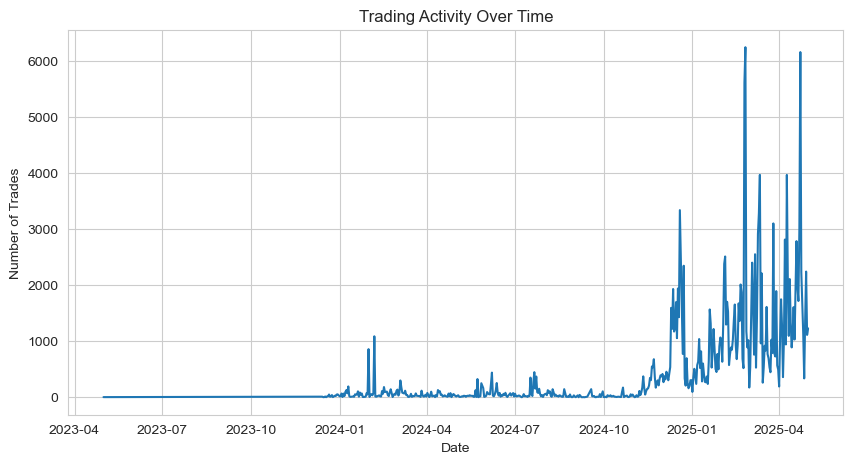

In [20]:
# Trades per day
trades_per_day = merged.groupby("date").size()

plt.figure(figsize=(10,5))
trades_per_day.plot()
plt.title("Trading Activity Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Trades")
plt.show()

## Trading Activity Over Time

This visualization shows how trading activity evolves over time.

Periods with higher trading activity may correspond to increased market volatility or strong market sentiment.

In [21]:
behavior = merged.groupby(["classification","Side"]).size().unstack()

behavior

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


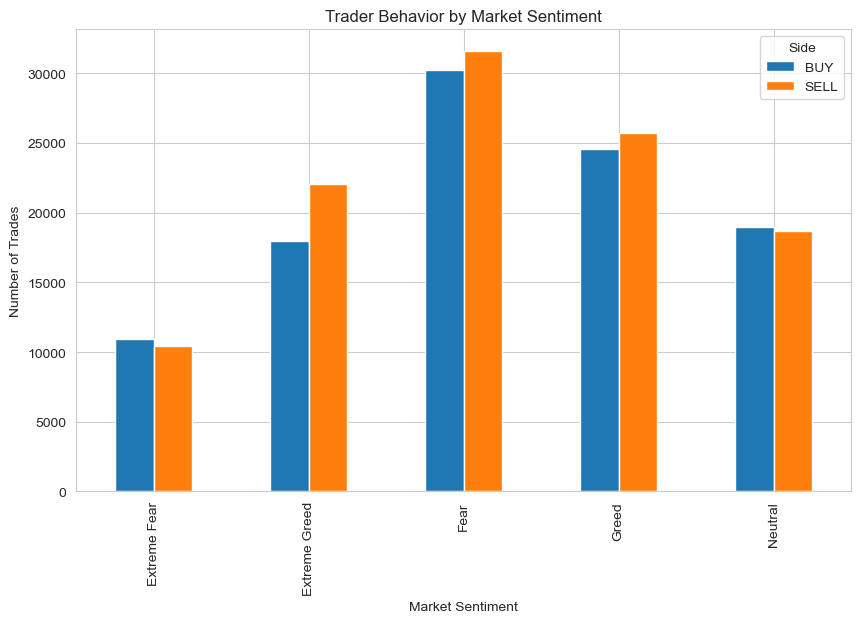

In [22]:
behavior.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Trader Behavior by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

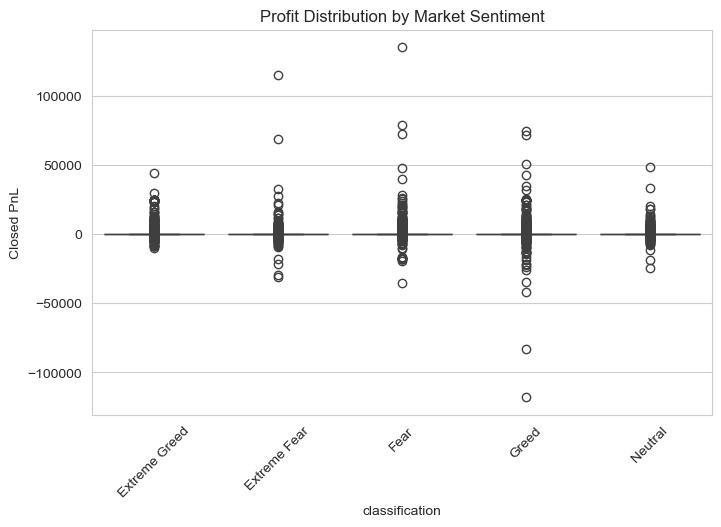

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="classification",
    y="Closed PnL",
    data=merged
)

plt.xticks(rotation=45)

plt.title("Profit Distribution by Market Sentiment")

plt.show()

In [24]:
top_traders = (
    merged.groupby("Account")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_traders

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64

## Top Traders Analysis

To understand trader performance, we identify the top 10 traders based on total closed profit (PnL).

This helps highlight the most successful participants in the dataset and provides insight into how profits are distributed among traders.

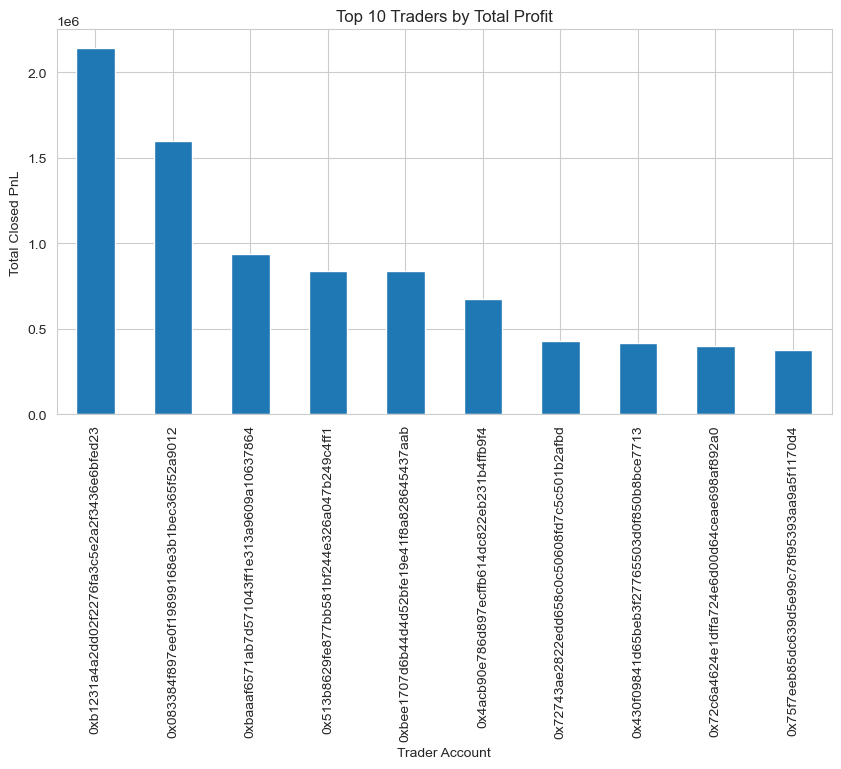

In [25]:
plt.figure(figsize=(10,5))

top_traders.plot(kind="bar")

plt.title("Top 10 Traders by Total Profit")
plt.ylabel("Total Closed PnL")
plt.xlabel("Trader Account")

plt.show()

In [26]:
volume = merged.groupby("classification")["Size USD"].sum()

volume

classification
Extreme Fear     1.144843e+08
Extreme Greed    1.244652e+08
Fear             4.833248e+08
Greed            2.885825e+08
Neutral          1.802421e+08
Name: Size USD, dtype: float64

## Trading Volume Distribution by Sentiment

This visualization shows how trading volume is distributed across different market sentiment categories.

It helps reveal whether traders are more active during fear-driven markets or greed-driven markets.

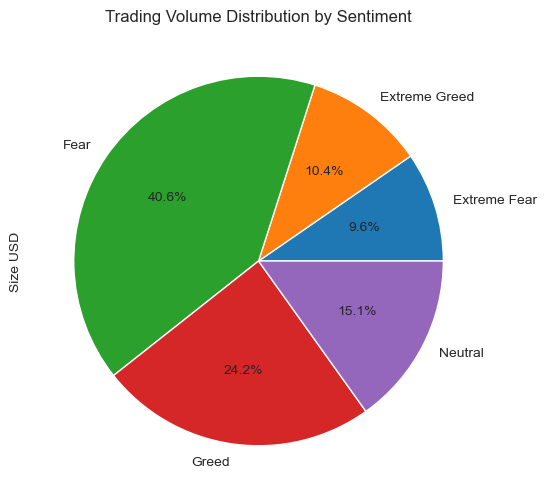

In [27]:
volume.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))

plt.title("Trading Volume Distribution by Sentiment")

plt.show()

## Key Insights

### Insight 1 — Trading activity increases during Fear markets
The volume distribution chart shows that a large portion of trading volume occurs during Fear or Extreme Fear conditions.  
This suggests that traders become more active during volatile or uncertain market periods.

### Insight 2 — Profitability varies across sentiment regimes
Average trader profitability differs across sentiment categories.  
Some sentiment regimes appear more favorable for profitable trading, indicating that market psychology influences trading outcomes.

### Insight 3 — A small group of traders generate most profits
The Top Traders analysis shows that profit distribution is highly concentrated among a few traders.  
This suggests that consistent trading performance is achieved by a small subset of participants.

## Strategy Recommendations

Based on the observed patterns between trader performance and market sentiment, the following strategy ideas emerge:

### Strategy 1 — Reduce leverage during Fear markets
Fear-driven markets are typically more volatile and unpredictable.  
Reducing leverage during these periods may help traders manage risk and avoid large drawdowns.

### Strategy 2 — Increase activity during neutral or stable sentiment periods
More stable sentiment conditions may allow traders to execute strategies with greater consistency.  
Focusing trading activity during these periods could improve overall performance stability.

## Conclusion

This analysis explored the relationship between trader performance and market sentiment using the Fear & Greed Index and historical trading data.

Key findings suggest that trader behavior and profitability vary across different sentiment regimes. Fear-driven markets appear to trigger higher trading activity, while profit distribution remains concentrated among a smaller group of traders.

These insights highlight the importance of adapting trading strategies based on prevailing market sentiment and managing risk appropriately during volatile conditions.